![figura](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)






In [ ]:
#!pip install skimpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import skew, kurtosis, kruskal
#from skimpy import skim


df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv')


df.head()



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


##Atividade: desenvolva uma AED, ao fim indique hipóteses e quais são as variaveis mais indicadas para prosseguir como entradas no modelo (descrever questões de atenção para termos com essas variáveis), objetivo: classificar as especieis de pinguim.

In [ ]:
#definir quais variaves vão ser numericas ou categoricas
for column in df.columns:
  if pd.api.types.is_numeric_dtype(df[column]) and df[column].nunique() <5:
    df[column] = df[column].astype('category')

  if not pd.api.types.is_numeric_dtype(df[column]):
    df[column] = df[column].astype('category')

df.dtypes

,0
species,category
island,category
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,category


In [ ]:
# Exibindo informações gerais sobre o dataset, como tipos de dados e valores nulos

df.info()

# Gerando estatísticas descritivas para as colunas numéricas

# vamos dar uma incrementada na função 'describe'
from scipy.stats import shapiro # Import Shapiro-Wilk test

def full_summary(df):
    # usa describe para gerar estatísticas básicas

    summary = df.describe().T # transposta

    # seleciona apenas as colunas numéricas para os cálculos

    numeric_cols = df.select_dtypes(include=['number']).columns


    summary['IQR'] =  df[numeric_cols].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))

    # adiciona skewness (assimetria)
    summary['skewness'] = df[numeric_cols].apply(lambda x: skew(x.dropna()))

    # adiciona  kurtosis (curtose)
    summary['kurtosis'] = df[numeric_cols].apply(lambda x: kurtosis(x.dropna()))

    # Adiciona teste de normalidade (Shapiro-Wilk)

    summary['shapiro_p_value'] = df[numeric_cols].apply(lambda x: shapiro(x.dropna())[1])


    return summary

#  resumo
full_summary(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   bill_length_mm     342 non-null    float64 
 3   bill_depth_mm      342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                333 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.3 KB


,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis,shapiro_p_value
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6,9.275,0.052885,-0.880765,1.119730e-05
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5,3.100,-0.142835,-0.911155,4.418821e-06
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0,23.000,0.344164,-0.987434,3.540136e-09
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0,1200.000,0.468264,-0.726243,3.679039e-08


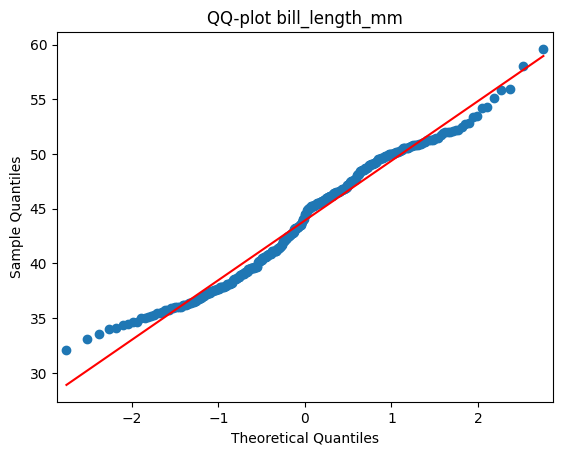

In [ ]:
# QQ-plot
sm.qqplot(df['bill_length_mm'].dropna(), line='s')
plt.title('QQ-plot bill_length_mm')
plt.show()

In [ ]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 344    │ │ float64     │ 4     │ │ species               │                                │
│ │ Number of columns │ 7      │ │ category    │ 3     │ │ island                │                                │
│ └───────────────────┴────────┘ └─────────────┴───────┘ │ sex                   │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA ┃ NA %               ┃ mean  ┃ sd    ┃ p0   ┃ p25   ┃ p50   ┃ p75  ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ bill_length_mm     │  2 │ 0.5813953488372093 │ 43.92 │  5.46 │ 32.1 │ 39.23 │ 44.45 │ 48.5 │ 59.6 │ ▃█▆█▃  │  │
│ │ bill_depth_mm      │  2 │ 0.5813953488372093 │ 17.15 │ 1.975 │ 13.1 │  15.6 │  17.3 │ 18.7 │ 21.5 │ ▄▅▆█▆▂ │  │
│ │ flipper_length_mm  │  2 │ 0.5813953488372093 │ 200.9 │ 14.06 │  172 │   190 │   197 │  213 │  231 │ ▂██▄▆▃ │  │
│ │ body_mass_g        │  2 │ 0.5813953488372093 │  4202 │   802 │ 2700 │  3550 │  4050 │ 4750 │ 6300 │ ▂█▆▄▃▁ │  │
│ └────────────────────┴────┴────────────────────┴───────┴───────┴──────┴───────┴───────┴──────┴──────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓  │
│ ┃ column             ┃ NA      ┃ NA %                                   ┃ ordered           ┃ unique         ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩  │
│ │ species            │       0 │                                      0 │ False             │              3 │  │
│ │ island             │       0 │                                      0 │ False             │              3 │  │
│ │ sex                │      11 │                      3.197674418604651 │ False             │              3 │  │
│ └────────────────────┴─────────┴────────────────────────────────────────┴───────────────────┴────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

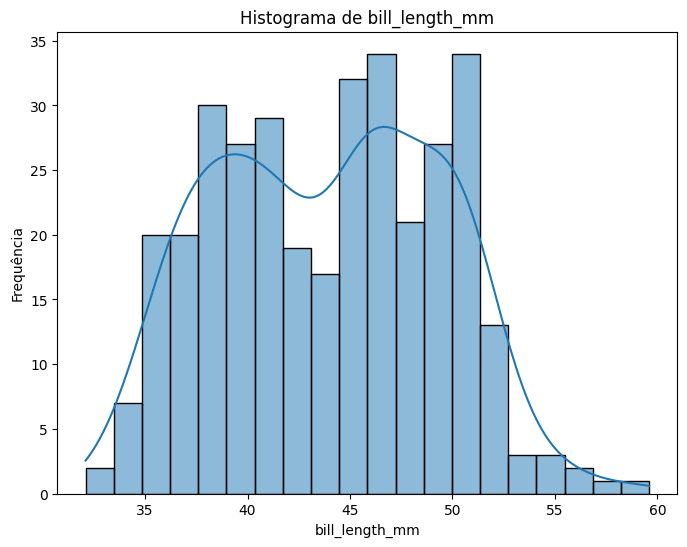

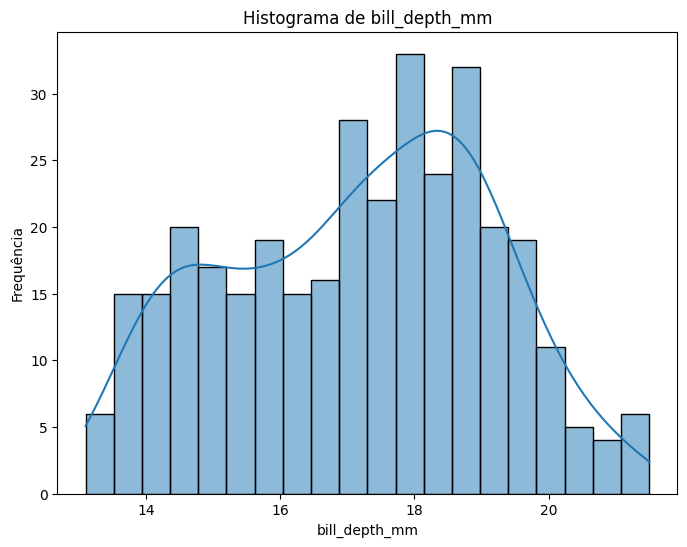

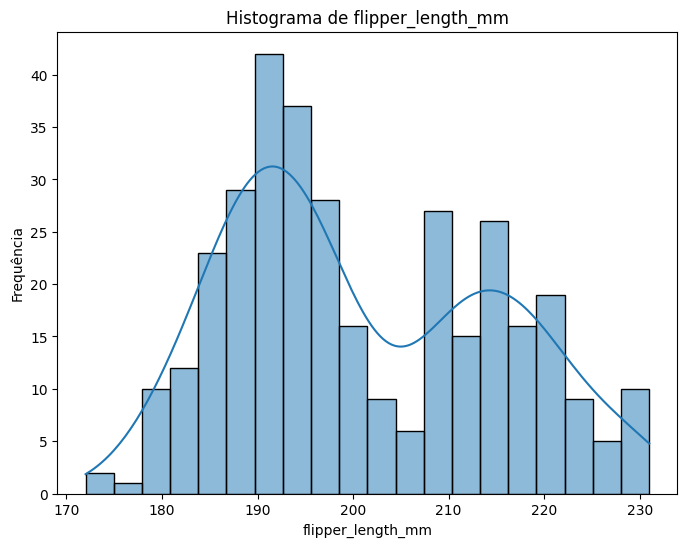

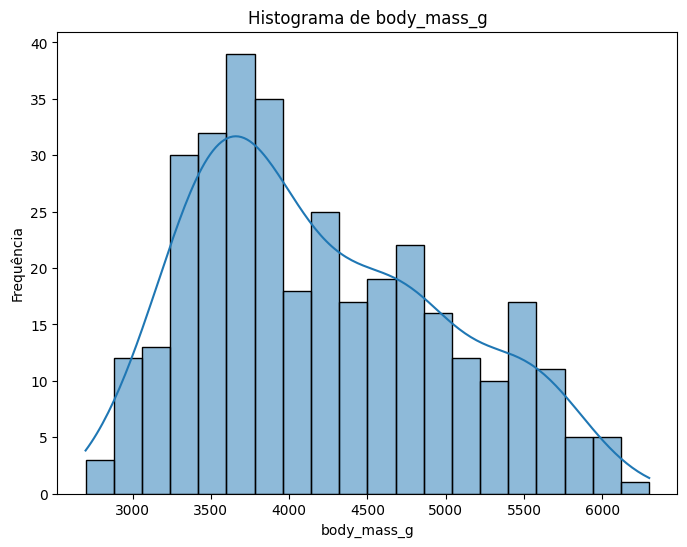

In [ ]:
# Gerar histogramas para as variáveis numéricas
for column in df.columns:
  if pd.api.types.is_numeric_dtype(df[column]):
    plt.figure(figsize=(8, 6))
    sns.histplot(df[column], kde=True,bins=20)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.show()

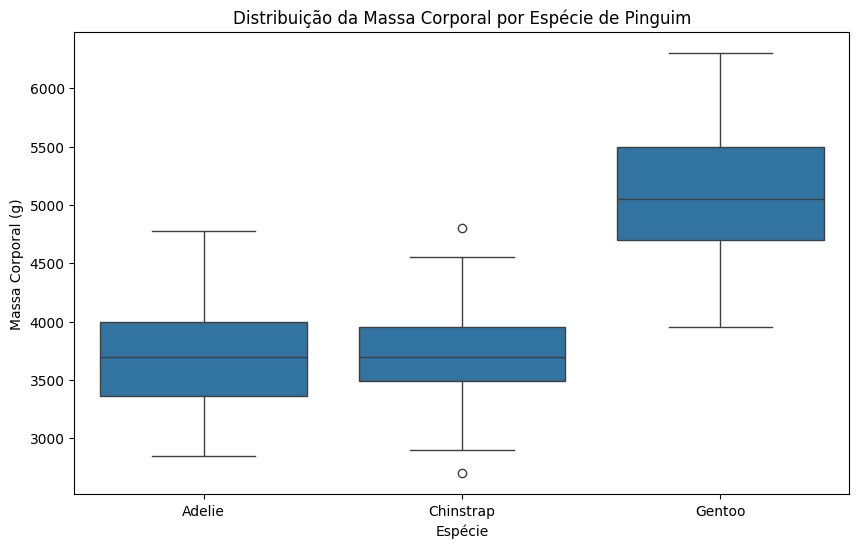

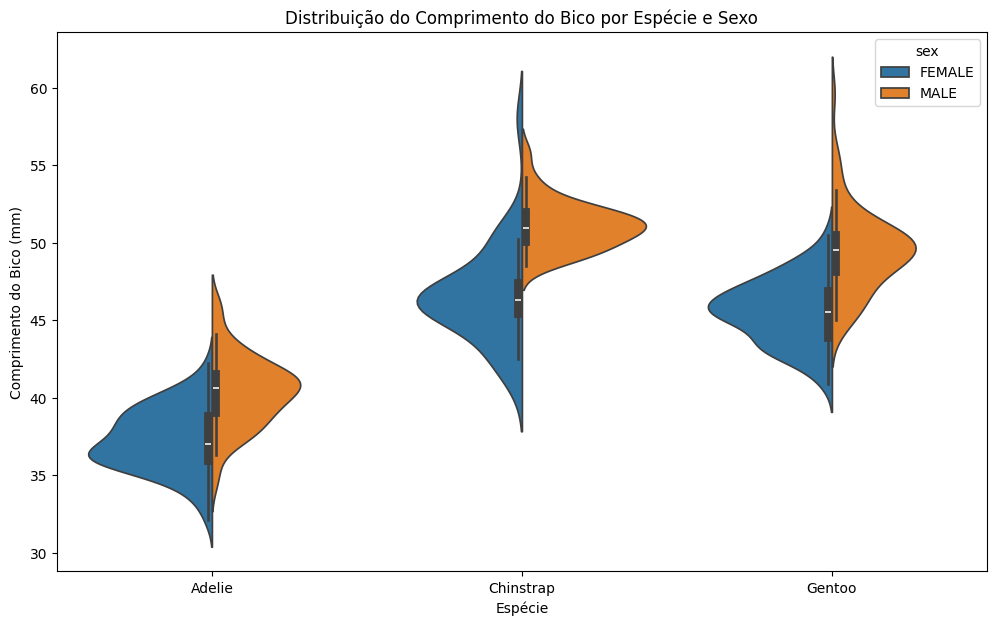

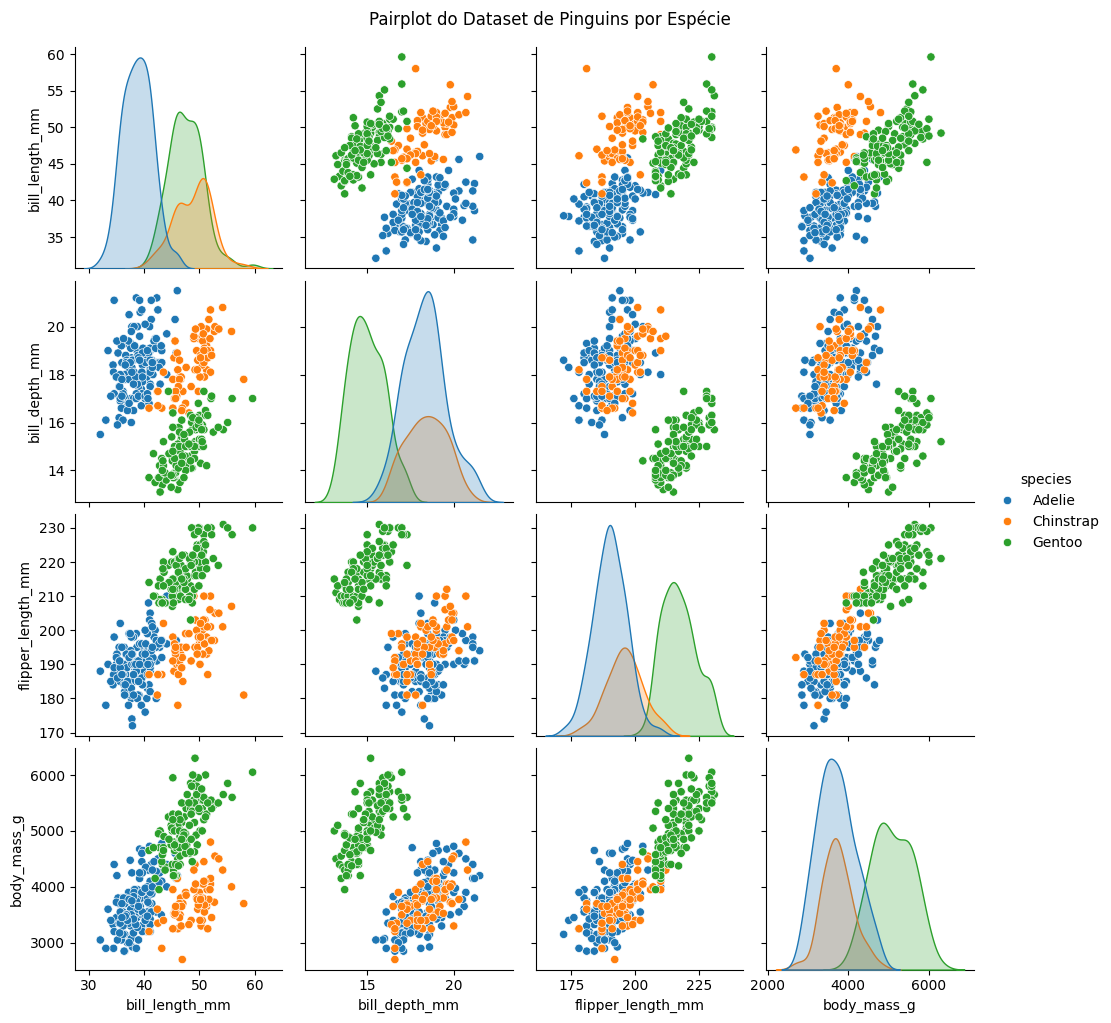

In [ ]:



# Boxplot: ideal para visualizar a distribuição da massa corporal por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='body_mass_g', data=df)
plt.title('Distribuição da Massa Corporal por Espécie de Pinguim')
plt.xlabel('Espécie')
plt.ylabel('Massa Corporal (g)')
plt.savefig('penguins_boxplot.png')

# Violin Plot: combina um boxplot com um gráfico de densidade
# Ótimo para mostrar a distribuição do comprimento do bico por espécie e sexo
plt.figure(figsize=(12, 7))
sns.violinplot(x='species', y='bill_length_mm', hue='sex', data=df, split=True)
plt.title('Distribuição do Comprimento do Bico por Espécie e Sexo')
plt.xlabel('Espécie')
plt.ylabel('Comprimento do Bico (mm)')
plt.savefig('penguins_violinplot.png')



# Pairplot: mostra a relação entre pares de variáveis, colorido por espécie
# É excelente para identificar padrões e correlações
sns.pairplot(df.dropna(), hue="species")
plt.suptitle('Pairplot do Dataset de Pinguins por Espécie', y=1.02)
plt.savefig('penguins_pairplot.png')



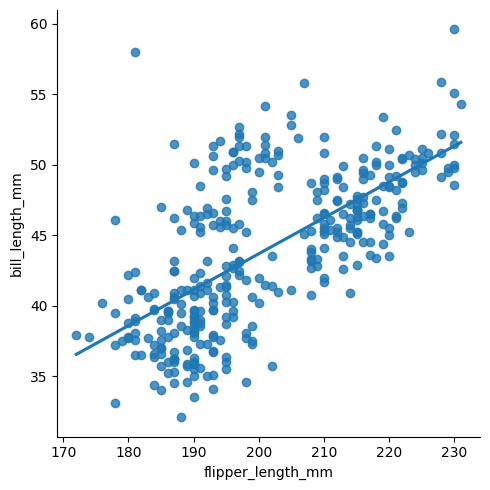

In [ ]:
sns.lmplot(x='flipper_length_mm', y='bill_length_mm', data=df, ci=None)

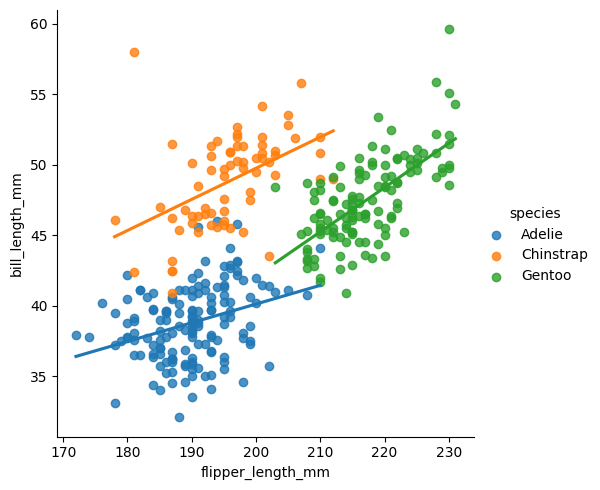

In [ ]:
sns.lmplot(x='flipper_length_mm', y='bill_length_mm',hue='species', data=df, ci=None)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


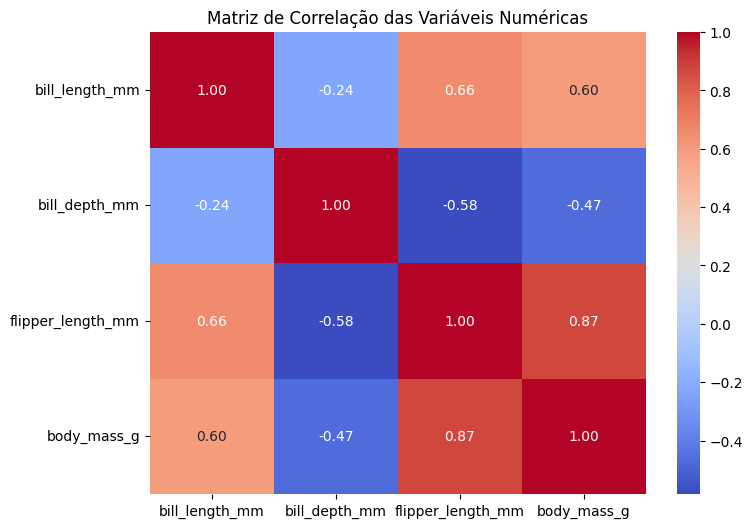

In [ ]:
# Calcular a matriz de correlação para as variáveis numéricas
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Exibir a matriz de correlação
display(correlation_matrix)

# Visualiza a matriz de correlação com um heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

In [ ]:
# Calcular a matriz de correlação para cada espécie separadamente
for species in df['species'].unique():
    print(f"Matriz de Correlação para a Espécie: {species}")
    species_df = df[df['species'] == species].select_dtypes(include=['number'])
    correlation_matrix_species = species_df.corr()
    display(correlation_matrix_species)
    print("\n")

Matriz de Correlação para a Espécie: Adelie


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.391492,0.325785,0.548866
bill_depth_mm,0.391492,1.000000,0.307620,0.576138
flipper_length_mm,0.325785,0.307620,1.000000,0.468202
body_mass_g,0.548866,0.576138,0.468202,1.000000




Matriz de Correlação para a Espécie: Chinstrap


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.653536,0.471607,0.513638
bill_depth_mm,0.653536,1.000000,0.580143,0.604498
flipper_length_mm,0.471607,0.580143,1.000000,0.641559
body_mass_g,0.513638,0.604498,0.641559,1.000000




Matriz de Correlação para a Espécie: Gentoo


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.643384,0.661162,0.669166
bill_depth_mm,0.643384,1.000000,0.706563,0.719085
flipper_length_mm,0.661162,0.706563,1.000000,0.702667
body_mass_g,0.669166,0.719085,0.702667,1.000000


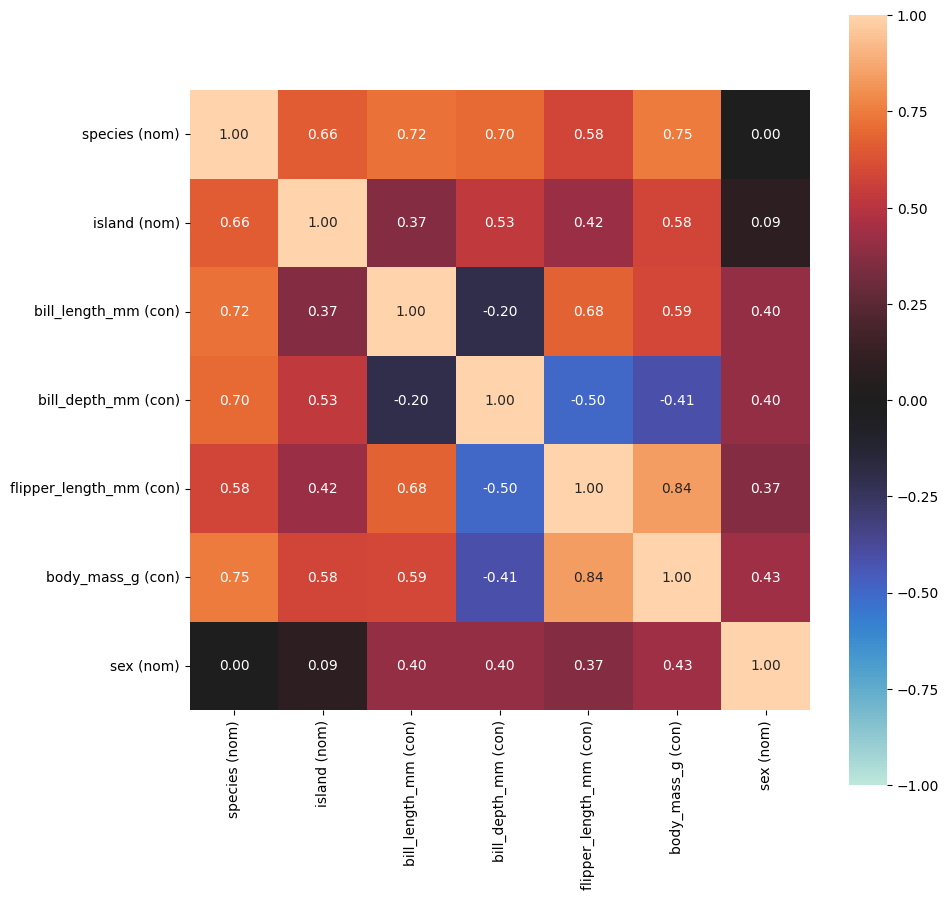

{'corr':                          species (nom)  island (nom)  bill_length_mm (con)  \
species (nom)                 1.000000      0.657329              0.721939   
island (nom)                  0.657329      1.000000              0.366195   
bill_length_mm (con)          0.721939      0.366195              1.000000   
bill_depth_mm (con)           0.697617      0.527699             -0.200559   
flipper_length_mm (con)       0.582445      0.419962              0.678449   
body_mass_g (con)             0.749210      0.580857              0.591019   
sex (nom)                     0.000000      0.087854              0.403885   

                         bill_depth_mm (con)  flipper_length_mm (con)  \
species (nom)                       0.697617                 0.582445   
island (nom)                        0.527699                 0.419962   
bill_length_mm (con)               -0.200559                 0.678449   
bill_depth_mm (con)                 1.000000                -0.496836   
f

In [ ]:
#!pip install dython

from dython import nominal

correlation_matrix = nominal.associations(df, figsize=(10,10), mark_columns=True, num_num_assoc='spearman')

# Mostra a matriz de correlação
print(correlation_matrix)

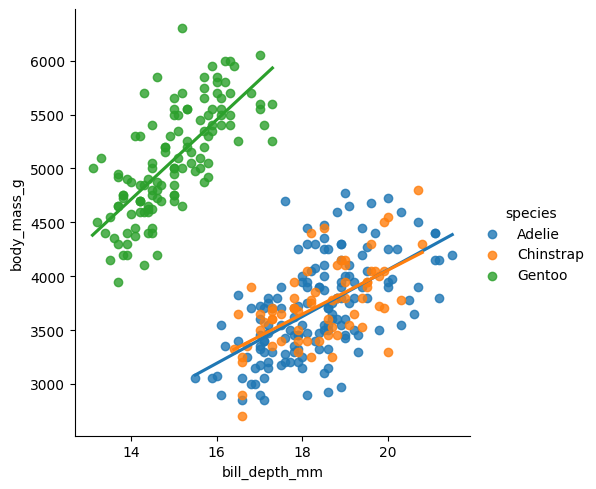

In [ ]:
sns.lmplot(x='bill_depth_mm', y='body_mass_g',hue='species', data=df, ci=None)

In [ ]:
# atenção para as variaveis categoricas
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd

# Remover valores ausentes
df.dropna(inplace=True)

# Copiar o dataset
df2 = df.copy()

# Identificar colunas categóricas que você quer transformar
cat_cols = ['island', 'sex', 'species']

# Aplicar LabelEncoder em cada coluna, transforma para numeros
# não é a melhor forma de se usar, veremos no proximo modulo.

for col in cat_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])


# Separar X e y
X = df2.drop('species', axis=1)
y = df2['species']

# Selecionador de features – Informação Mútua
selector = SelectKBest(score_func=mutual_info_classif, k=3)
selector.fit(X, y)

# Scores das features
all_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

# Features selecionadas
selected_features = X.columns[selector.get_support()]

print("--- Informação Mútua ---\n")
print(all_scores)
print("\nMelhores features:")
print(list(selected_features))

--- Informação Mútua ---

flipper_length_mm    0.606716
bill_depth_mm        0.581088
bill_length_mm       0.556833
island               0.518630
body_mass_g          0.513145
sex                  0.020810
dtype: float64

Melhores features:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
# 1. Filtrar o X para conter apenas as 2 melhores colunas selecionadas pelo seu SelectKBest
X_selecionado = X[['bill_length_mm', 'flipper_length_mm']]

# 2. Dividir em Treino (80%) e Teste (20%)
# O 'stratify=y' garante que o treino e o teste tenham a mesma proporção de cada espécie de flor
X_train, X_test, y_train, y_test = train_test_split(
    X_selecionado, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features que serão usadas no modelo: {list(X_selecionado.columns)}")
print(f"Quantidade de linhas para Treino: {X_train.shape[0]}")
print(f"Quantidade de linhas para Teste: {X_test.shape[0]}")


#Instancia o modelo de árvore bem simplificado
modelo_arvore = DecisionTreeClassifier(max_depth=3, random_state=42)

#Treina o modelo usando apenas as 2 features selecionadas
modelo_arvore.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Faz as previsões no conjunto de teste
y_pred = modelo_arvore.predict(X_test)

#Mostra os resultados de performance

print(f"Acurácia Geral no Teste: {accuracy_score(y_test, y_pred):.2%}\n")


Features que serão usadas no modelo: ['bill_length_mm', 'flipper_length_mm']
Quantidade de linhas para Treino: 266
Quantidade de linhas para Teste: 67
Acurácia Geral no Teste: 94.03%



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Usar o df2 e as colunas X e y já preparadas
# df2 já foi tratado para NaN e codificado em LabelEncoder no passo anterior

# Re-definir X usando as features selecionadas do passo anterior (mutual info)
X = df2[list(selected_features)]
#X = df2[list(selected_features) + ['sex']].drop('bill_depth_mm', axis=1)
y = df2['species']

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Inicializar o modelo KNN
# Podemos ajustar o número de vizinhos (n_neighbors) para otimizar o modelo
knn = KNeighborsClassifier(n_neighbors=5)

# Treinar o modelo
knn.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = knn.predict(X_test)

# Avaliar o desempenho do modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Acurácia do modelo KNN: {accuracy:.4f}")
print("\nRelatório de Classificação:\n")
print(report)


Acurácia do modelo KNN: 0.9900

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       1.00      0.94      0.97        18
           2       1.00      1.00      1.00        34

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100



## Dados sobre a qualidade de vinhos, vamos explorar

In [ ]:
# pacote para o repositorio da UCI http://archive.ics.uci.edu/
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# cada dataset tem seu id
wine_quality = fetch_ucirepo(id=186)

# data (
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# informações
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Concatenando para facilitar a análise
df = pd.concat([X, y], axis=1)

# Espiada inicial (Primeiras linhas)
print(df.head())

# Raio-X da estrutura (Tipos e Nulos)
print(df.info())

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [ ]:
# prestem atenção no aviso do shapiro!
full_summary(df)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6497.
  res = hypotest_fun_out(*samples, **kwds)


,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis,shapiro_p_value
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000,1.30000,1.722892,5.056343,2.437973e-57
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000,0.17000,1.494751,2.822275,6.255995e-58
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000,0.14000,0.471622,2.394471,5.262332e-37
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000,6.30000,1.435073,4.354994,1.757308e-64
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100,0.02700,5.398581,50.857966,1.453455e-80
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000,24.00000,1.219784,7.899231,5.790497e-45
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000,79.00000,-0.001177,-0.372301,1.566012e-27
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898,0.00465,0.503485,6.600061,1.322803e-35
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000,0.21000,0.386749,0.366451,2.204049e-19
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000,0.17000,1.796855,8.646117,3.382989e-54


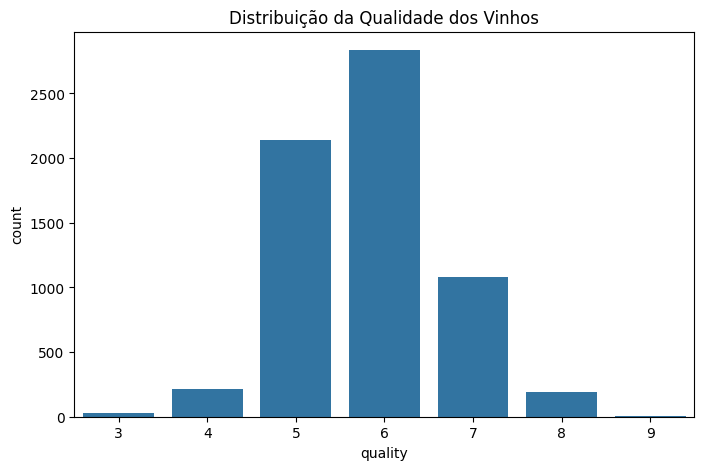

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df)
plt.title('Distribuição da Qualidade dos Vinhos')
plt.show()

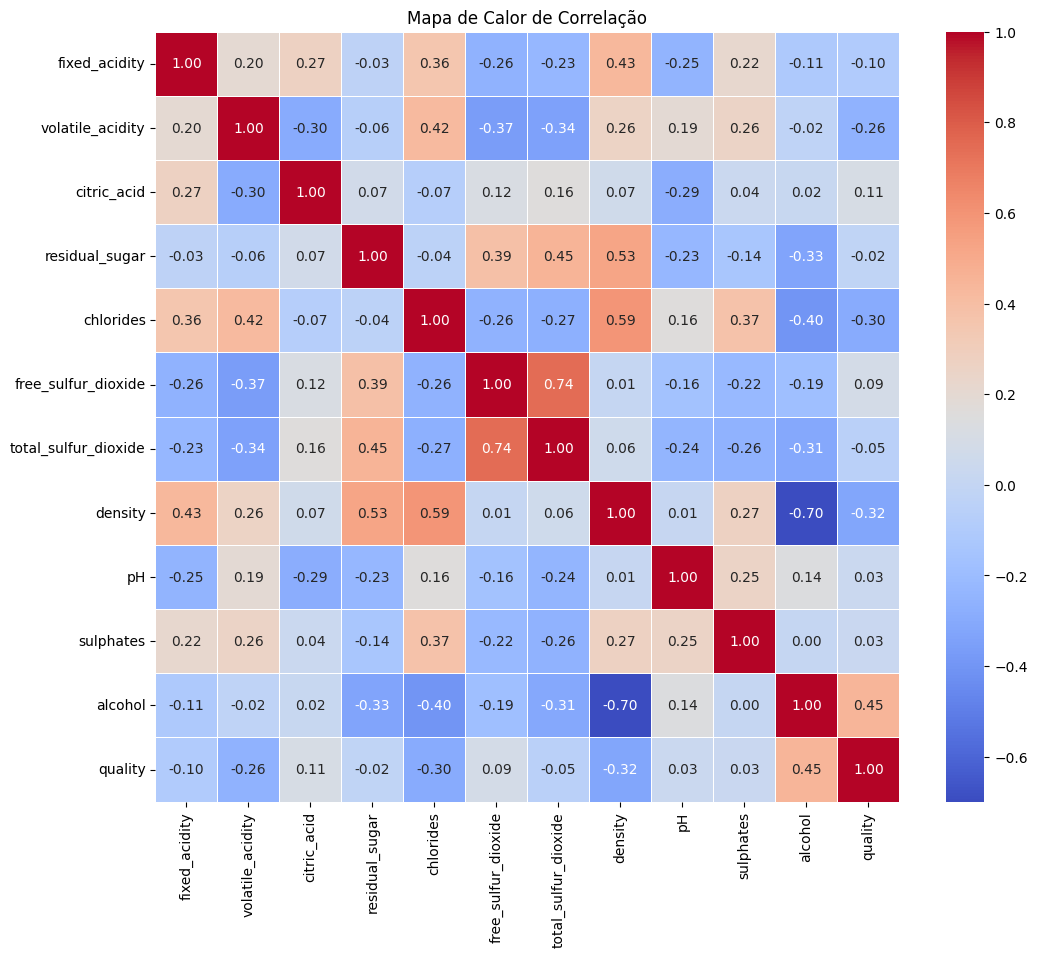

In [ ]:
plt.figure(figsize=(12, 10))

# Matriz de correlação
correlation_matrix = df.corr("spearman")

# Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlação')
plt.show()

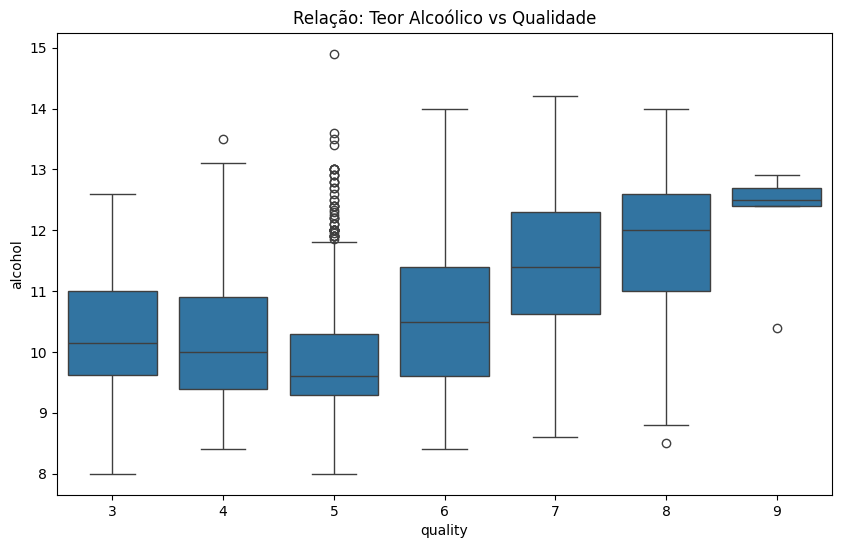

In [ ]:
# relação do teor alccólico com a qualidade
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Relação: Teor Alcoólico vs Qualidade')
plt.show()

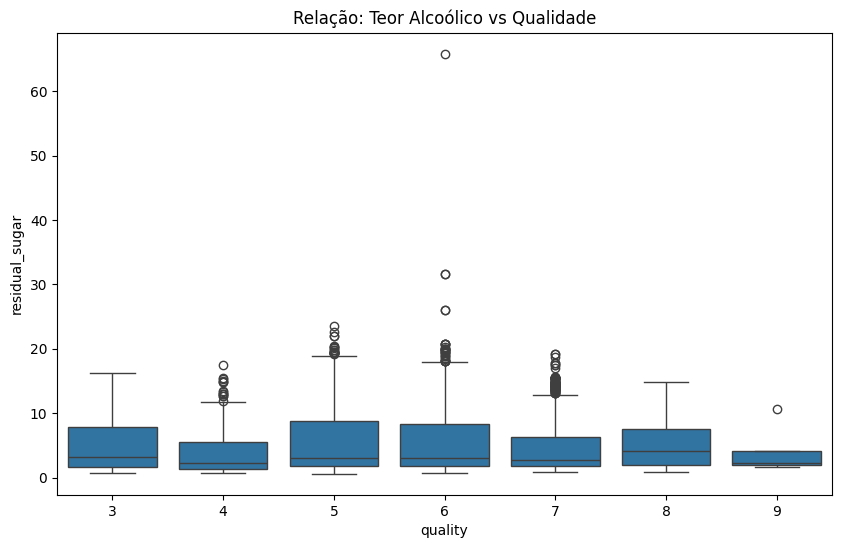

In [ ]:
# e o açucar, tem alguma relação com a qualidade?
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='residual_sugar', data=df)
plt.title('Relação: Teor açucar vs Qualidade')
plt.show()

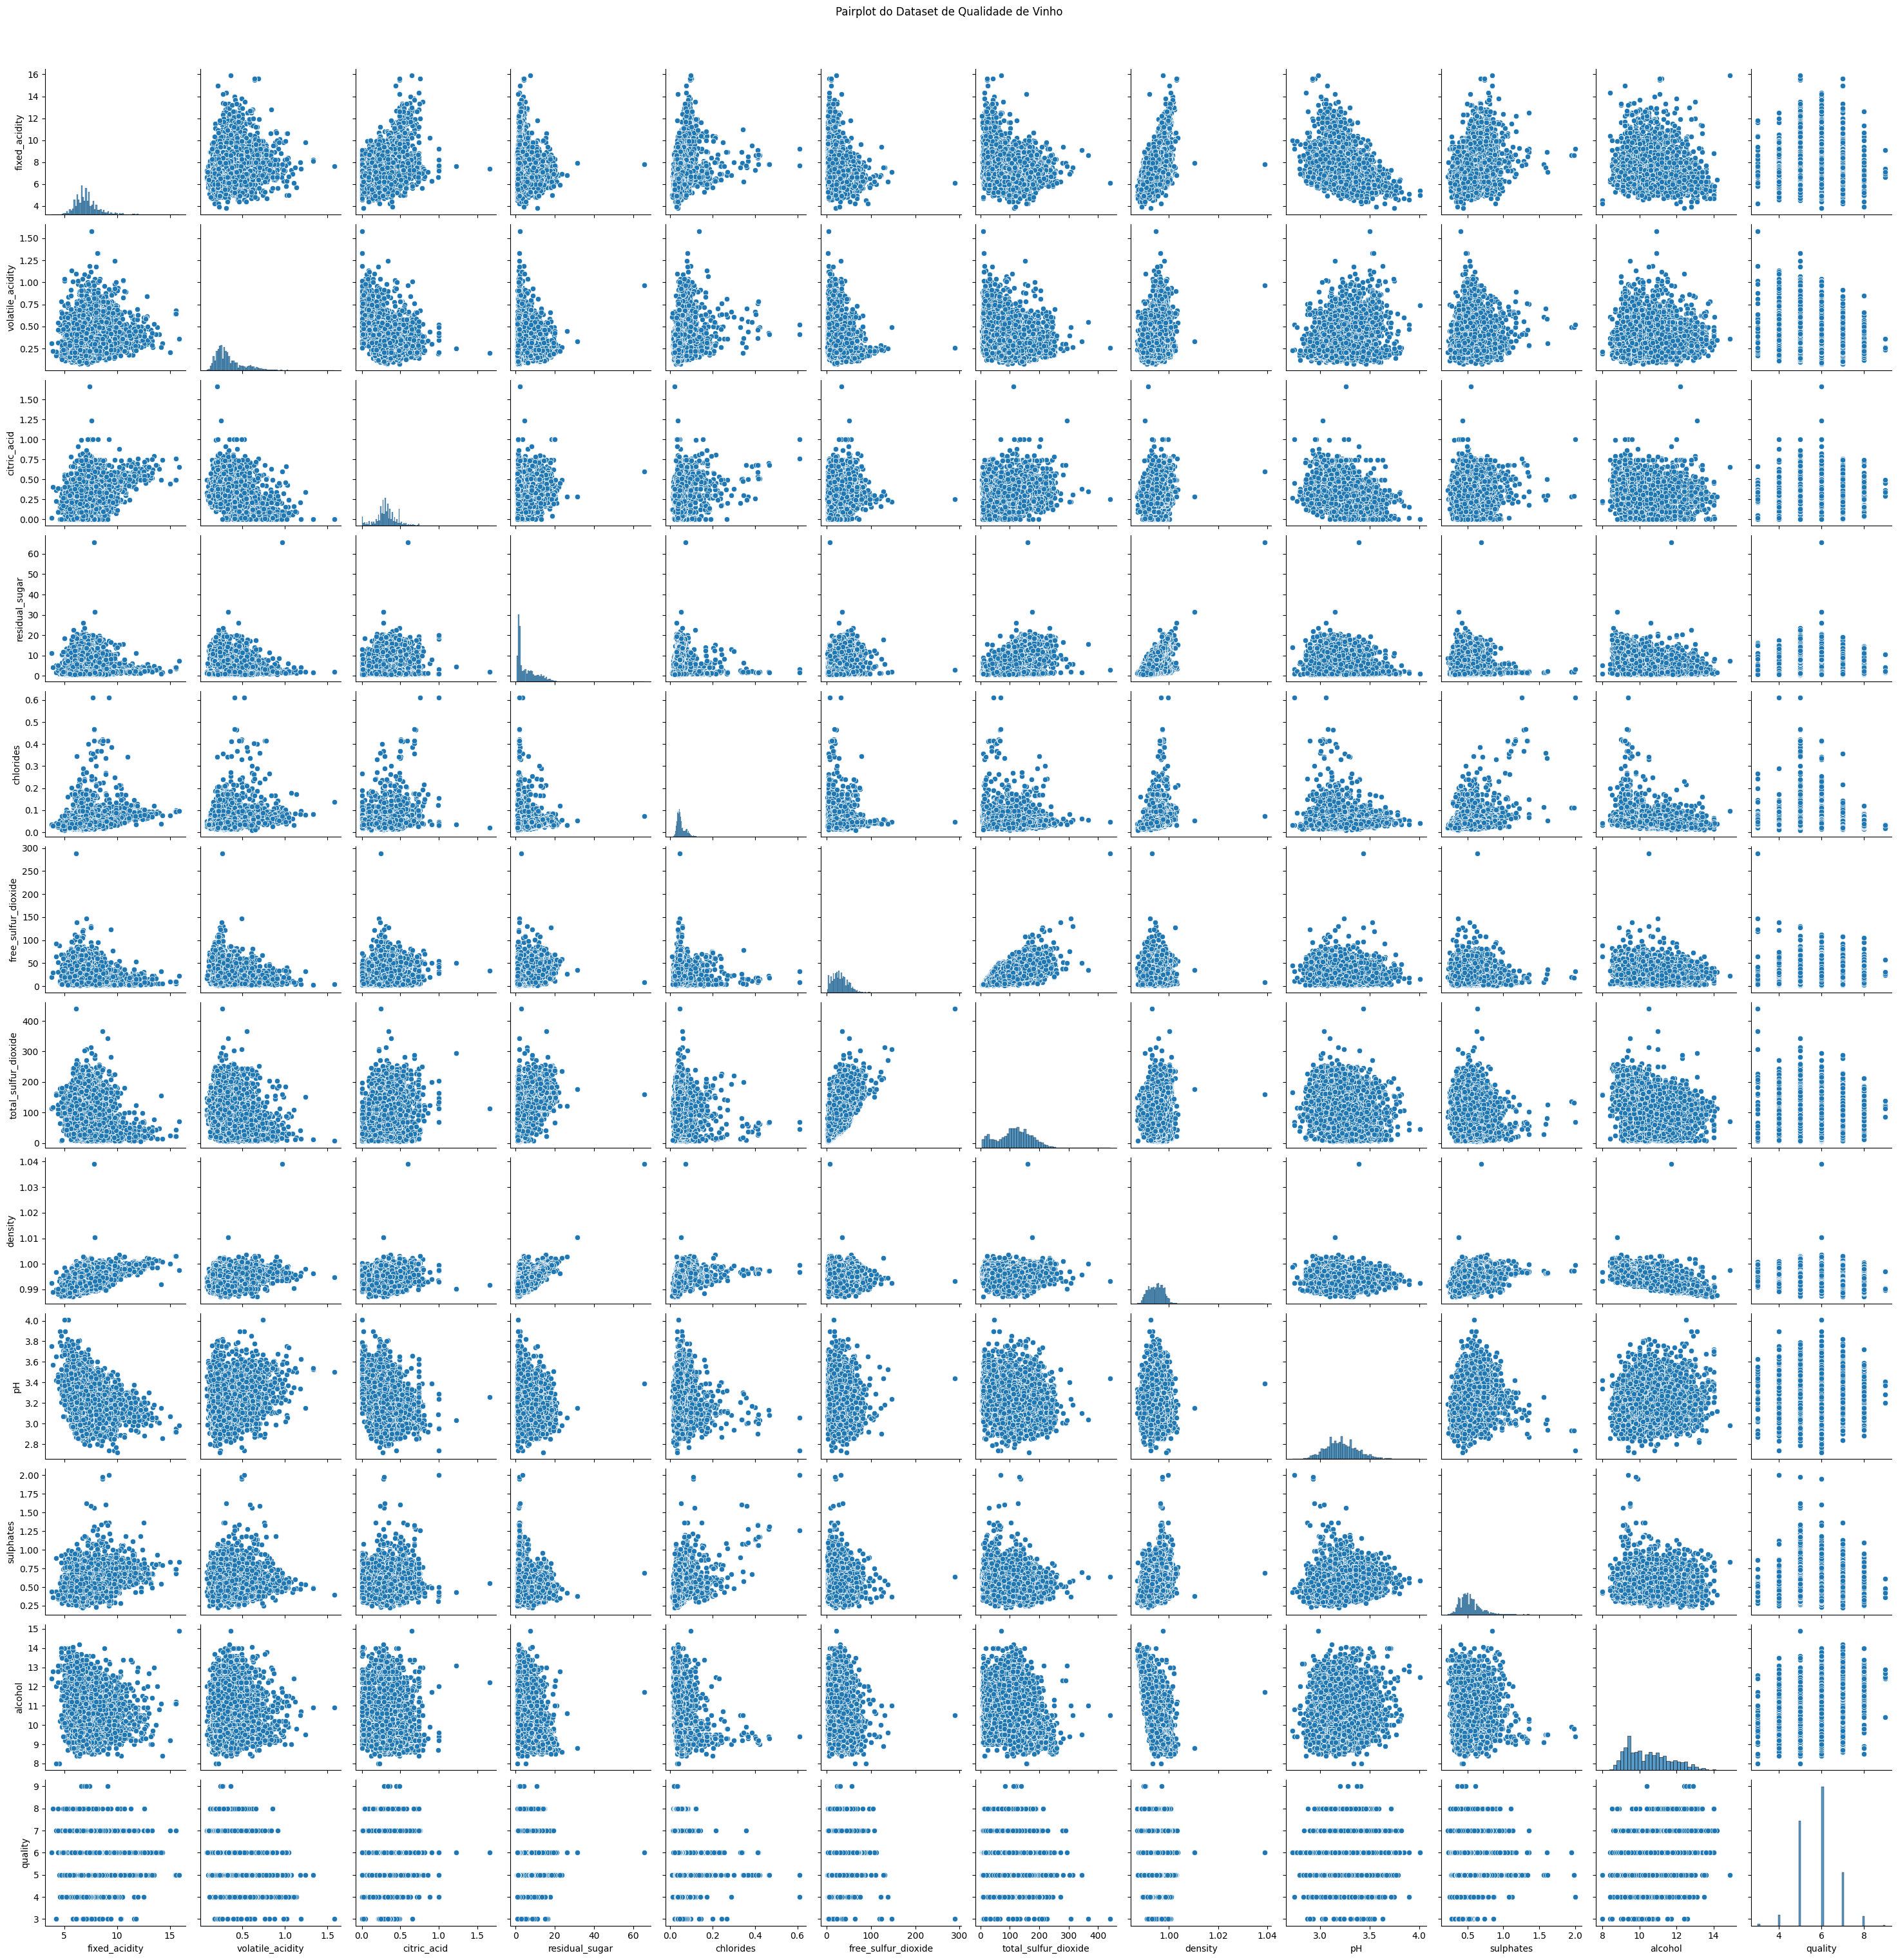

In [ ]:
# nosso classico grafico para relações, sera que ajuda?
sns.pairplot(df)
plt.suptitle('Pairplot do Dataset de Qualidade de Vinho', y=1.02)
plt.show()

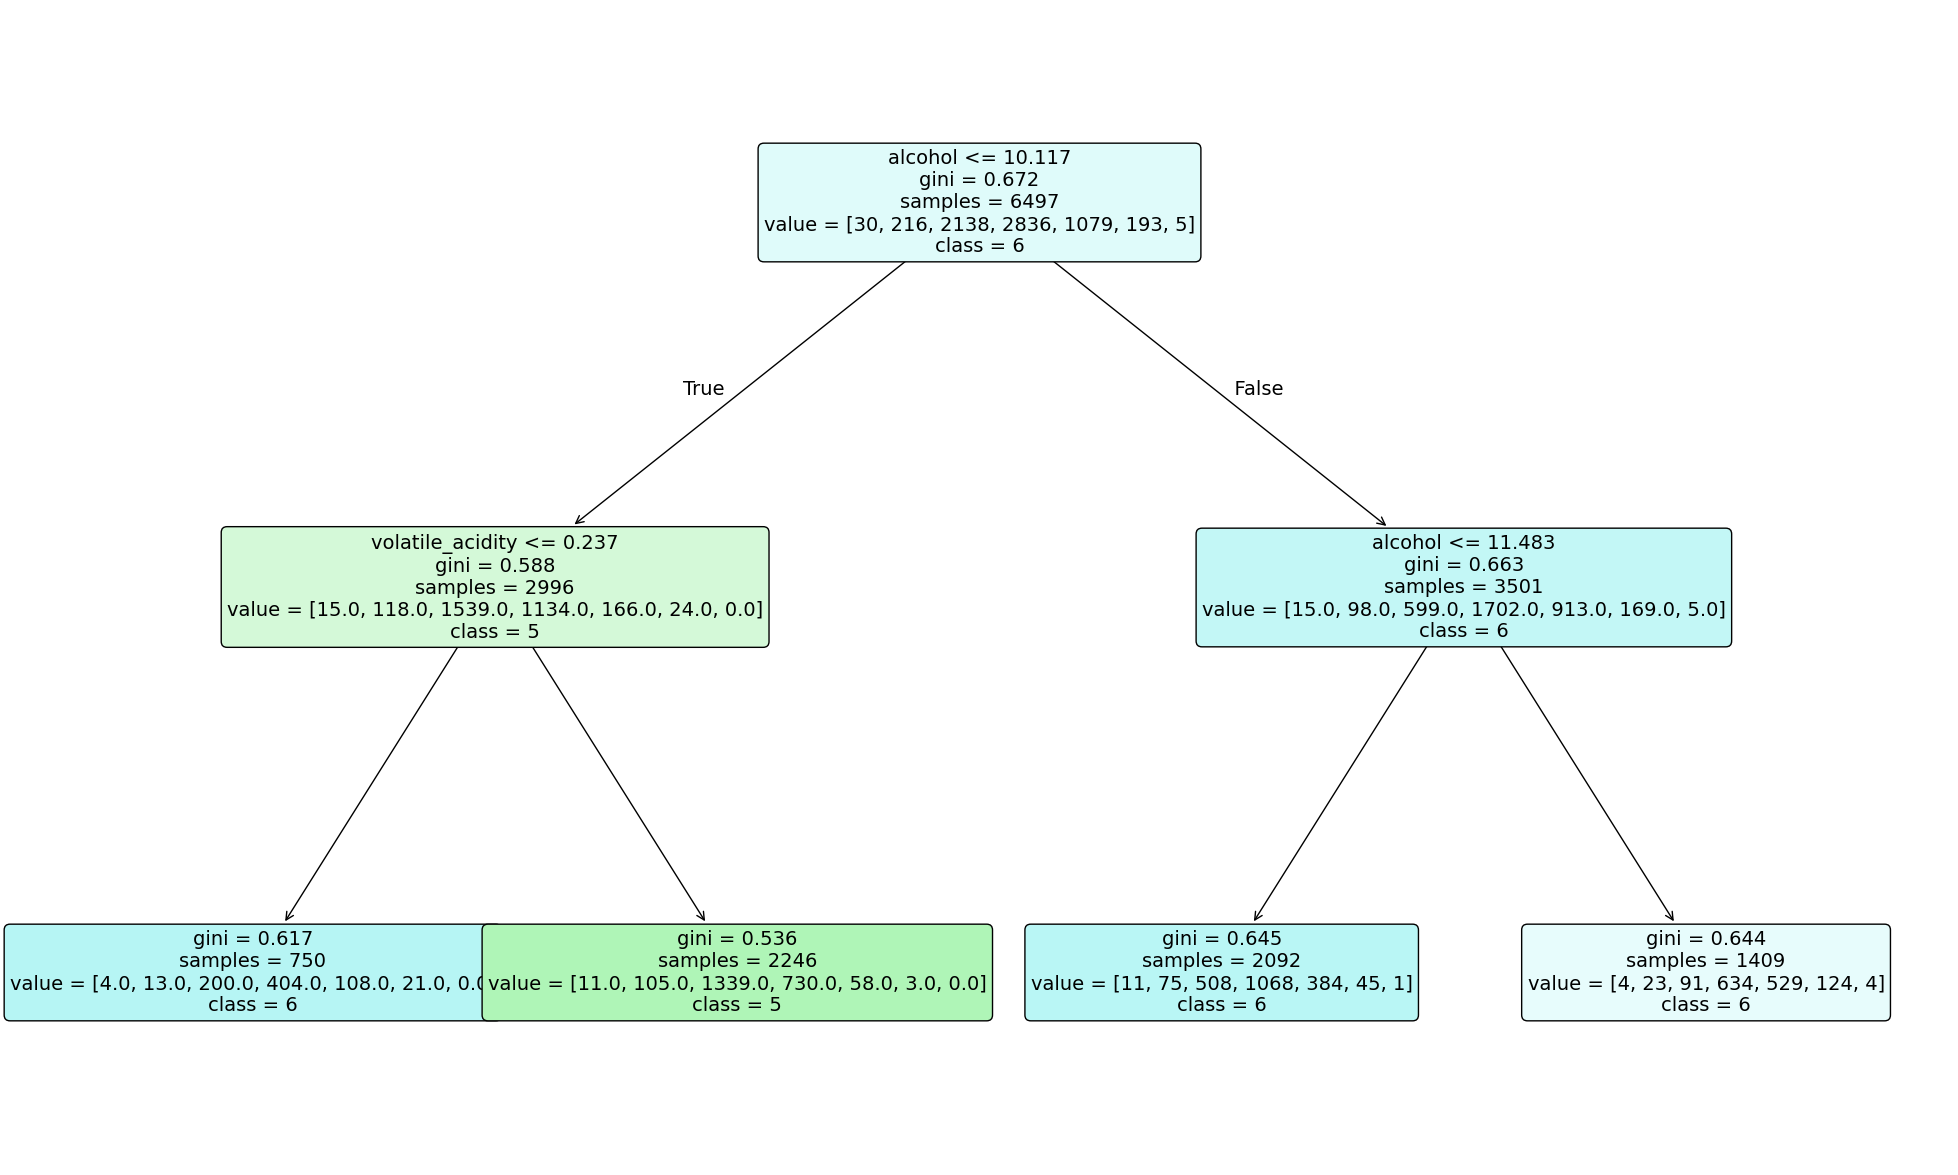

In [ ]:
# ainda não trabalhamos com modelos, mas a arvore de decisão é uma boa opção para encontrar padrões ocultos.

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


X_wine = df.drop('quality', axis=1)
y_wine = df['quality']

# arvore de profundidade =2
dt_classifier = DecisionTreeClassifier(max_depth=2, random_state=2025)

# treinamento do modelo
dt_classifier.fit(X_wine, y_wine)

plt.figure(figsize=(25, 15))

# ver a arvore
plot_tree(dt_classifier,
          feature_names=X_wine.columns,
          class_names=sorted(y_wine.unique().astype(str)),
          filled=True,
          rounded=True,
          fontsize=14)

plt.show()



In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd

df_wine = pd.concat([X, y], axis=1)

# Separar X e y para o dataset de vinhos
X_wine_mi = df_wine.drop('quality', axis=1)
y_wine_mi = df_wine['quality']

# Selecionador de features – Informação Mútua
# Usamos k='all' para calcular o MI para todas as features
selector_wine = SelectKBest(score_func=mutual_info_classif, k='all')
selector_wine.fit(X_wine_mi, y_wine_mi)

# Scores das features
wine_mi_scores = pd.Series(selector_wine.scores_, index=X_wine_mi.columns).sort_values(ascending=False)

print("--- Informação Mútua das variáveis para a Qualidade do Vinho ---\n")
print(wine_mi_scores)


--- Informação Mútua das variáveis para a Qualidade do Vinho ---

alcohol                 0.170175
density                 0.153482
chlorides               0.076139
total_sulfur_dioxide    0.069404
residual_sugar          0.056814
volatile_acidity        0.056294
citric_acid             0.043709
free_sulfur_dioxide     0.041463
sulphates               0.037522
fixed_acidity           0.015785
pH                      0.000801
dtype: float64


Que conclusão podemos chegar?

## Vamos tentar um dataset do concreto e sua resistencia

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

# data (as pandas dataframes)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets

# metadata
print(concrete_compressive_strength.metadata)

# variable information
print(concrete_compressive_strength.variables)

{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Juntando X e y
df = pd.concat([X, y], axis=1)


# Dicionário de renomeação para facilitar nossa vida
novos_nomes = {
    df.columns[0]: 'cimento',
    df.columns[1]: 'escoria',        # Blast Furnace Slag
    df.columns[2]: 'cinzas',         # Fly Ash
    df.columns[3]: 'agua',
    df.columns[4]: 'superplast',     # Superplasticizer
    df.columns[5]: 'agregado_grosso',# Coarse Aggregate
    df.columns[6]: 'agregado_fino',  # Fine Aggregate
    df.columns[7]: 'idade',          # Age (dias)
    df.columns[8]: 'resistencia'     # Target (MPa)
}

df = df.rename(columns=novos_nomes)

print(df.head())

   cimento  escoria  cinzas   agua  superplast  agregado_grosso  \
0    540.0      0.0     0.0  162.0         2.5           1040.0   
1    540.0      0.0     0.0  162.0         2.5           1055.0   
2    332.5    142.5     0.0  228.0         0.0            932.0   
3    332.5    142.5     0.0  228.0         0.0            932.0   
4    198.6    132.4     0.0  192.0         0.0            978.4   

   agregado_fino  idade  resistencia  
0          676.0     28        79.99  
1          676.0     28        61.89  
2          594.0    270        40.27  
3          594.0    365        41.05  
4          825.5    360        44.30  


In [ ]:
full_summary(df)

,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis,shapiro_p_value
cimento,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0,157.625,0.508739,-0.523948,2.081700e-16
escoria,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4,142.950,0.799550,-0.511532,5.795510e-33
cinzas,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1,118.300,0.536571,-1.328125,4.134698e-36
agua,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0,27.100,0.074520,0.115670,1.462977e-10
superplast,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2,10.200,0.905881,1.398608,9.064747e-29
agregado_grosso,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0,97.400,-0.040161,-0.601932,8.347135e-10
agregado_fino,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6,93.050,-0.252641,-0.107501,1.841960e-10
idade,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0,49.000,3.264415,12.104177,7.718419e-44
resistencia,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6,22.425,0.416370,-0.318024,9.010083e-11


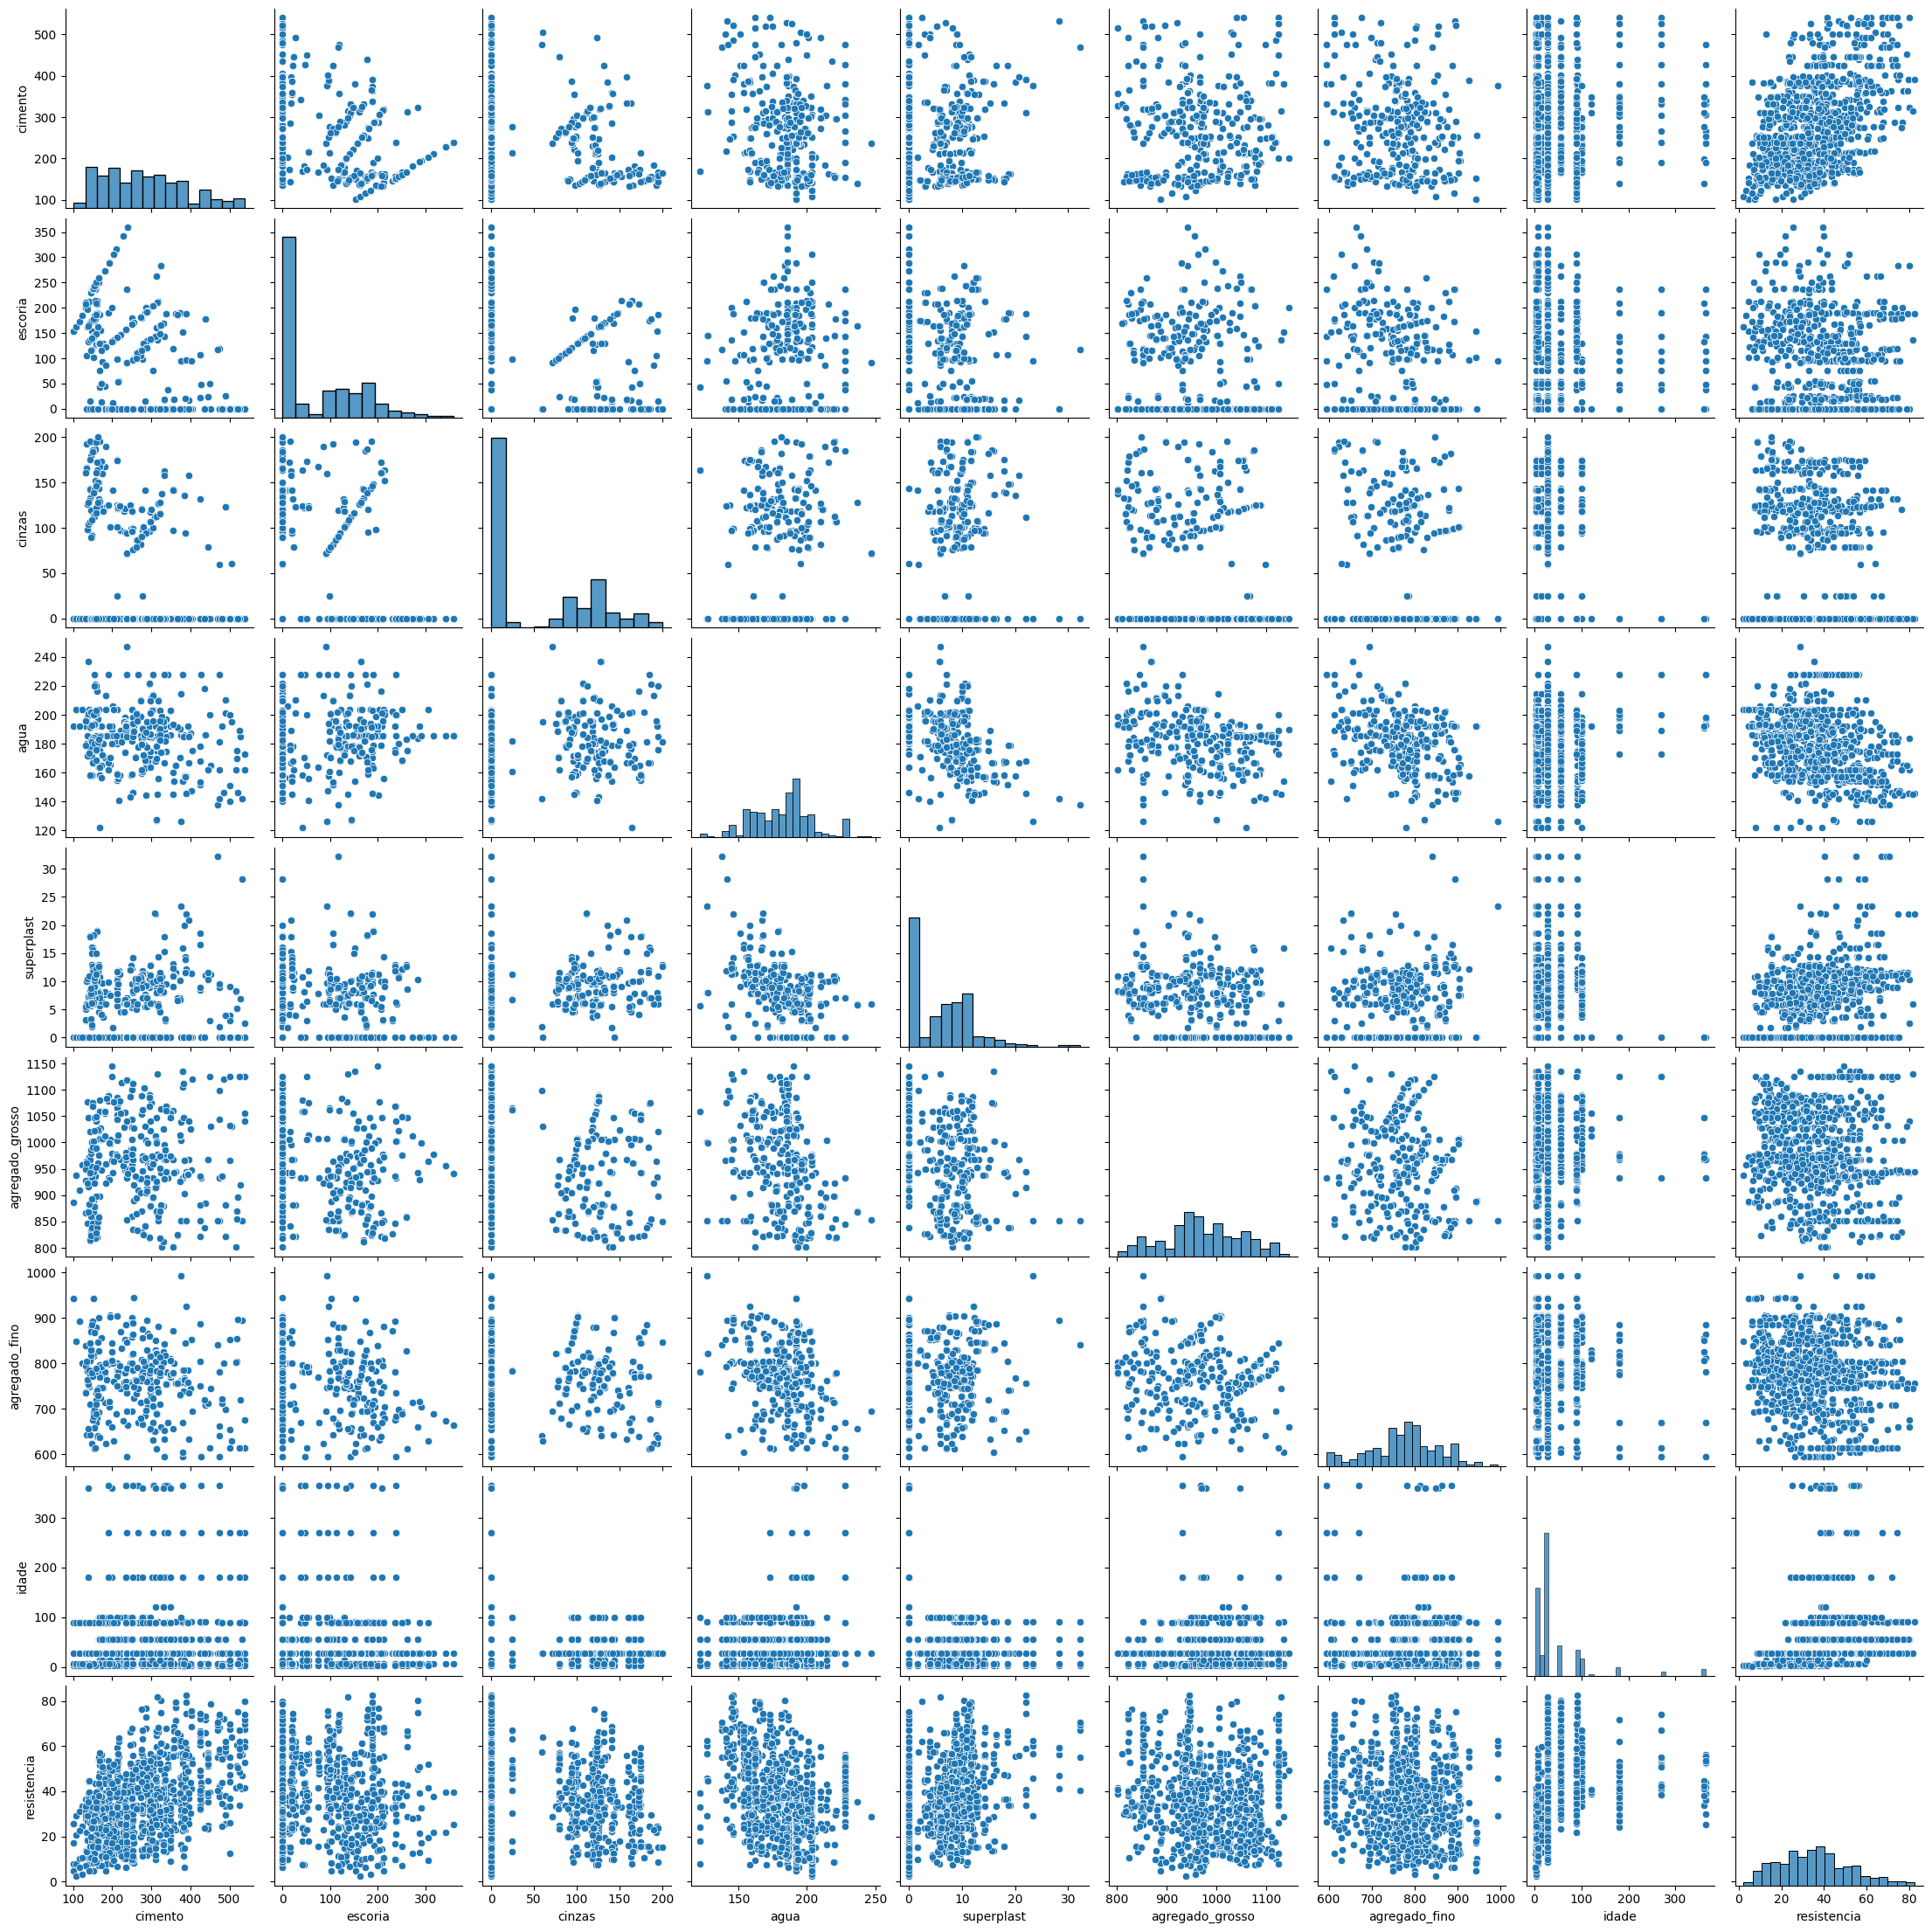

In [ ]:
sns.pairplot(df)

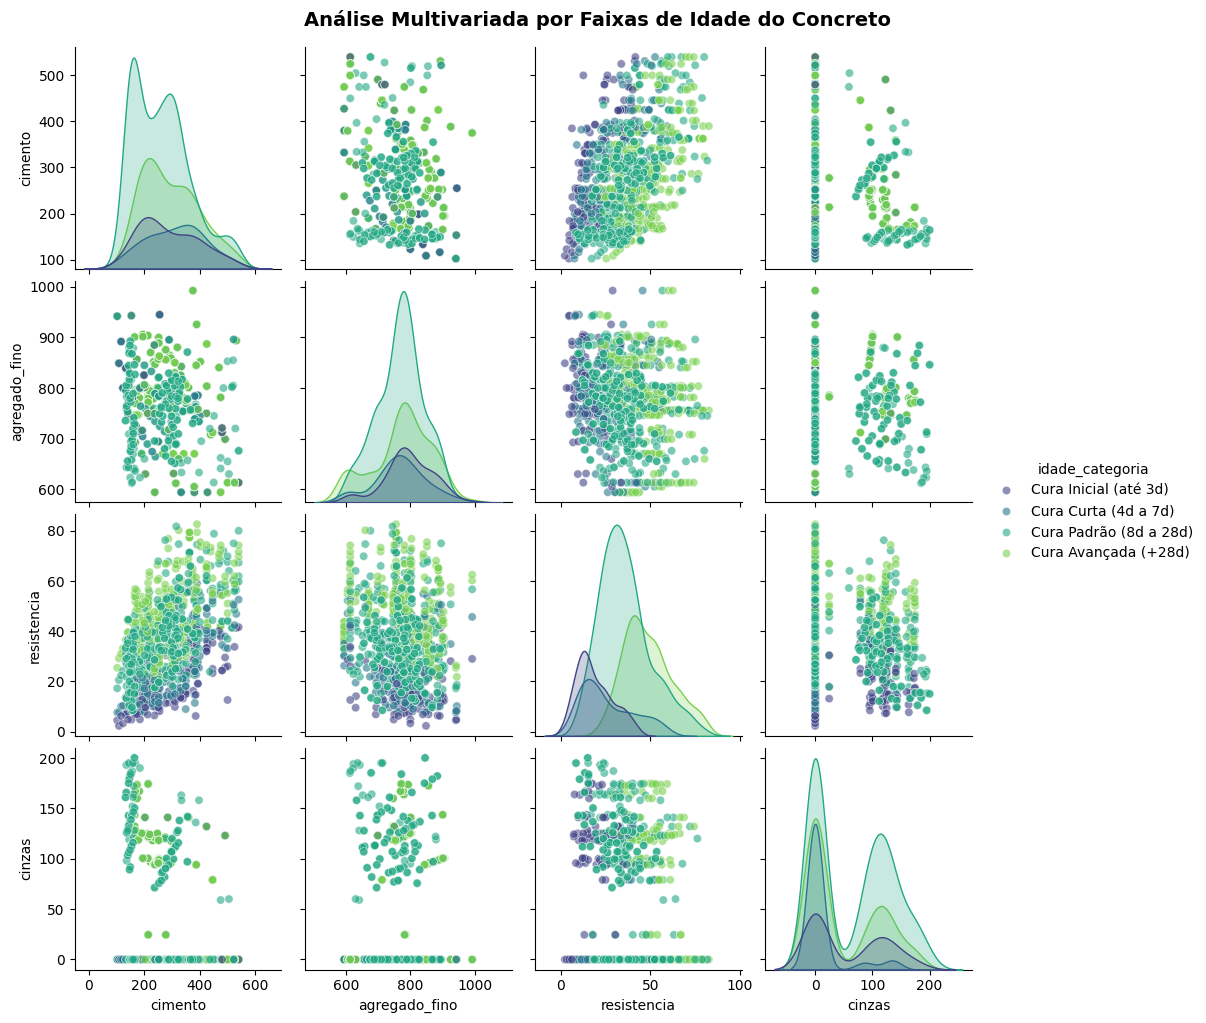

In [ ]:


# Definindo as faixas (bins) para a idade do concreto usando a engenharia civil
bins = [0, 3, 7, 28, float('inf')]
labels = ['Cura Inicial (até 3d)', 'Cura Curta (4d a 7d)', 'Cura Padrão (8d a 28d)', 'Cura Avançada (+28d)']

#Criando a nova coluna categórica usando o novo nome
df['idade_categoria'] = pd.cut(df['idade'], bins=bins, labels=labels, include_lowest=True)

# definindo as variáveis para o gráfico com base nos novos nomes


colunas_para_plot = ['cimento', 'agregado_fino', 'resistencia','cinzas']


# Criando o Pairplot
sns.pairplot(
    df[colunas_para_plot + ['idade_categoria']],
    hue='idade_categoria',
    palette='viridis',
    diag_kind='kde', # Gráfico de densidade suave nas diagonais
    plot_kws={'alpha': 0.6} # Transparência para evitar pontos totalmente sobrepostos
)

plt.suptitle("Análise Multivariada por Faixas de Idade do Concreto", y=1.02, fontsize=14, fontweight='bold')
plt.show()

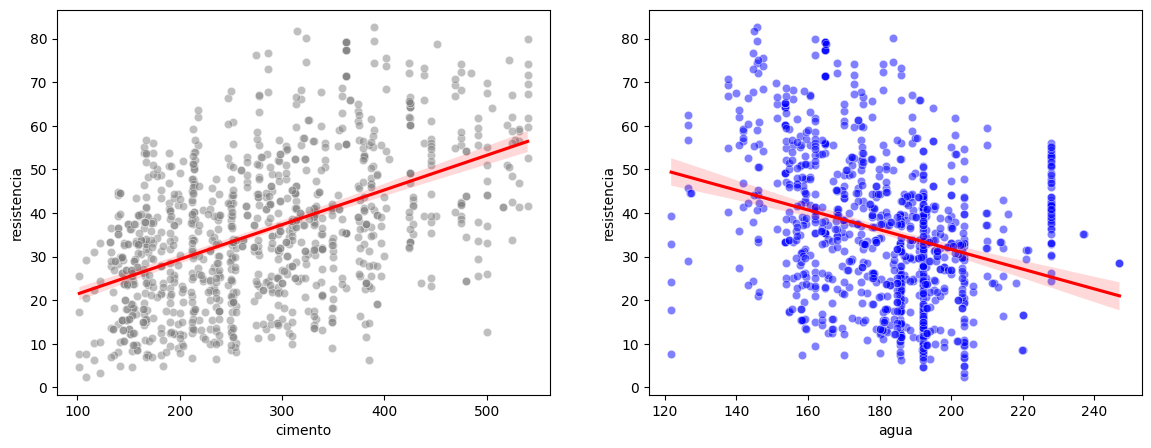

In [ ]:
plt.figure(figsize=(14, 5))

#Cimento vs Resistência
plt.subplot(1, 2, 1)
sns.scatterplot(x='cimento', y='resistencia', data=df, alpha=0.5, color='grey') # pontos
sns.regplot(x='cimento', y='resistencia', data=df, scatter=False, color='red') # reta de regressão linear


# Água vs Resistência
plt.subplot(1, 2, 2)
sns.scatterplot(x='agua', y='resistencia', data=df, alpha=0.5, color='blue')
sns.regplot(x='agua', y='resistencia', data=df, scatter=False, color='red')


plt.show()

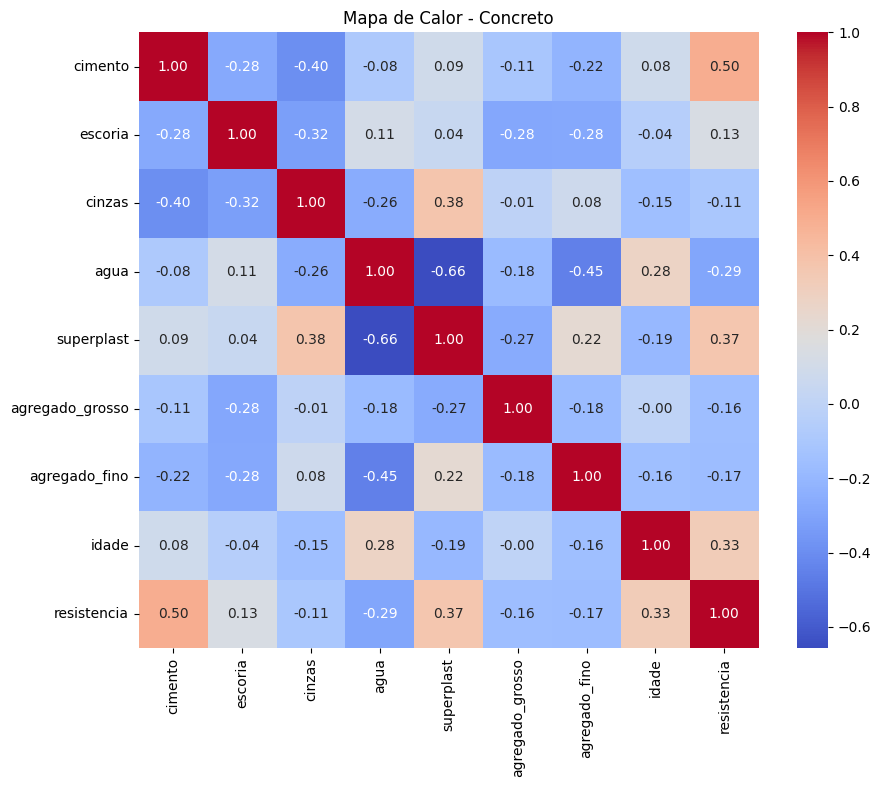

In [ ]:
# voltaremos nesse grafico
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor - Concreto')
plt.show()

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# Preparando os dados

X = df.drop('resistencia', axis=1)
y = df['resistencia']

# calculando o MI
#
mi_scores = mutual_info_regression(X, y, random_state=42)

# Organizando em uma Série Pandas para facilitar a visualização
mi_series = pd.Series(mi_scores, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

print("Pontuação de Informação Mútua (Feature Importance):")
print(mi_series)

Pontuação de Informação Mútua (Feature Importance):
idade              0.354497
agua               0.352715
cimento            0.308667
agregado_grosso    0.257885
agregado_fino      0.212918
superplast         0.209576
escoria            0.180882
cinzas             0.125545
dtype: float64


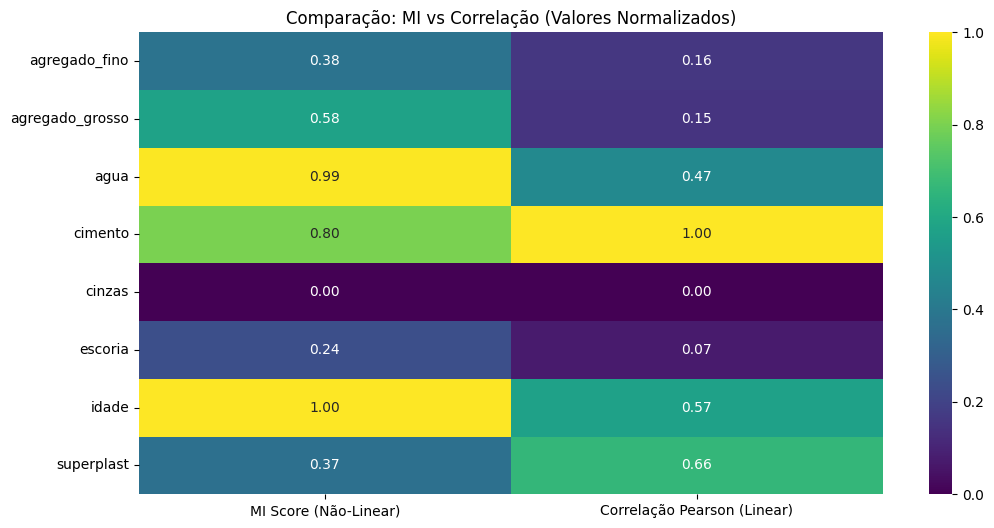

In [ ]:
# Calculando correlação absoluta com o alvo (macete)
corr_scores = df.corr()['resistencia'].drop('resistencia').abs()

# Criando um DataFrame comparativo
comparativo = pd.DataFrame({
    'MI Score (Não-Linear)': mi_series,
    'Correlação Pearson (Linear)': corr_scores
})

# Normalizando os valores (Min-Max) apenas para podermos comparar visualmente na mesma escala (0 a 1)
comparativo_norm = (comparativo - comparativo.min()) / (comparativo.max() - comparativo.min())

# Plotando o comparativo
plt.figure(figsize=(12, 6))
sns.heatmap(comparativo_norm, annot=True, cmap='viridis', fmt=".2f")
plt.title('Comparação: MI vs Correlação (Valores Normalizados)')
plt.show()

Refazer usando spearman ao invez de pearson

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Separar as features (X) e o target (y) para o dataset de concreto
X_concrete = df.drop(['resistencia'], axis=1)
y_concrete = df['resistencia']

# Dividir os dados em conjuntos de treinamento e teste
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_concrete, y_concrete, test_size=0.2, random_state=2025)

# Inicializar o modelo Random Forest Regressor
# Um número pequeno de estimadores (árvores) para um modelo 'simples' e rápido.
rfr_model = RandomForestRegressor(n_estimators=100, random_state=2025, n_jobs=-1) # n_jobs=-1 para usar todos os cores

# Treinar o modelo
rfr_model.fit(X_train_c, y_train_c)

# Fazer previsões no conjunto de teste
y_pred_c = rfr_model.predict(X_test_c)

# Avaliar o desempenho do modelo
mae = mean_absolute_error(y_test_c, y_pred_c)
mse = mean_squared_error(y_test_c, y_pred_c)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_c, y_pred_c)

print(f"--- Avaliação do Modelo Random Forest Regressor ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")


--- Avaliação do Modelo Random Forest Regressor ---
Mean Absolute Error (MAE): 3.54
Mean Squared Error (MSE): 29.57
Root Mean Squared Error (RMSE): 5.44
R-squared (R²): 0.89


E se usar as features mais representativas como forçantes? use as 3 melhores features que julgares necessaria

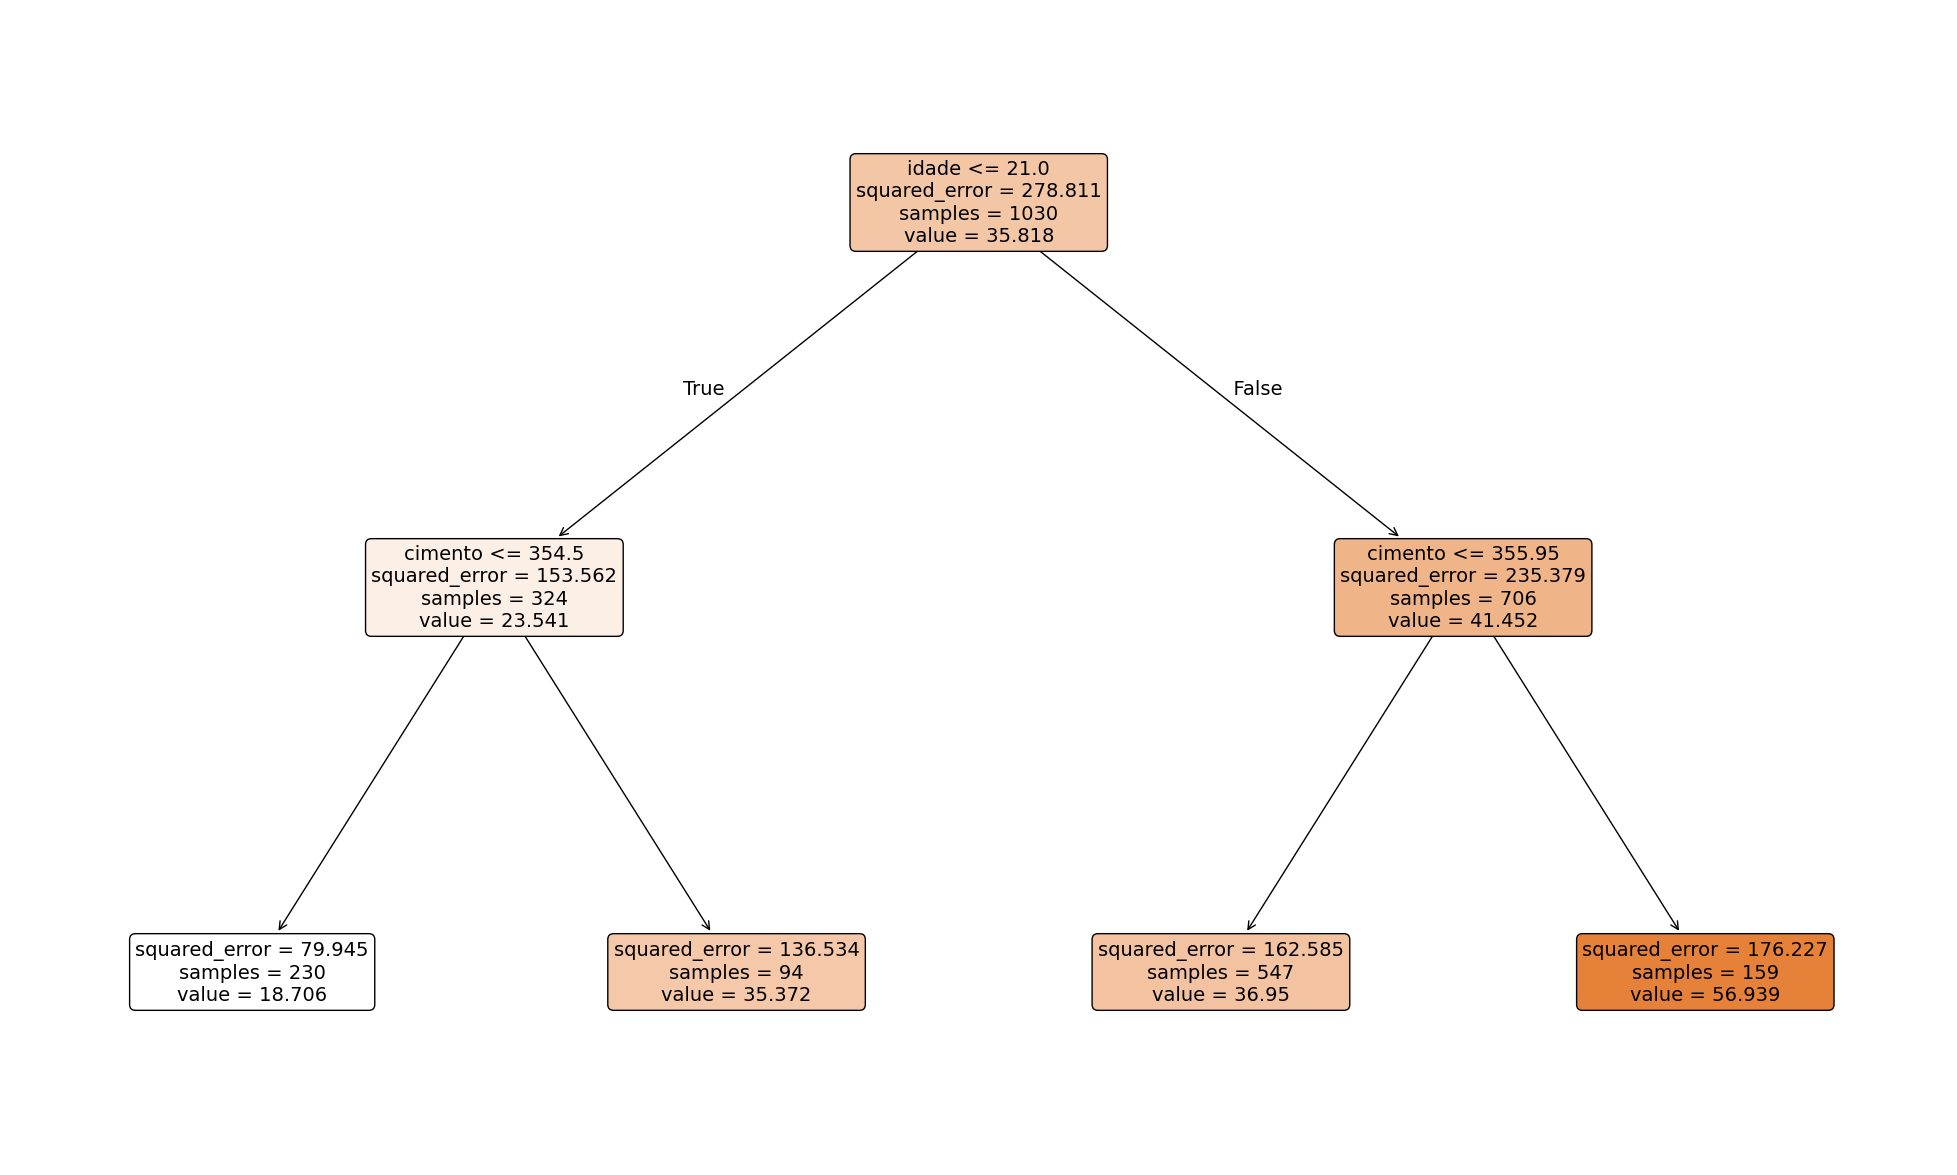

In [ ]:
#Criar uma arvore simples pode uma boa maneira de visualizar relações
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

X_concrete = df.drop(['resistencia'], axis=1)
y_concrete = df['resistencia']

# arvore de profundidade =3
dt_classifier = DecisionTreeRegressor(max_depth=2, random_state=2025)

# treinamento do modelo
dt_classifier.fit(X_concrete, y_concrete)

plt.figure(figsize=(25, 15))

# ver a arvore
plot_tree(dt_classifier,
          feature_names=X_concrete.columns,
          class_names=sorted(y_concrete.unique().astype(str)),
          filled=True,
          rounded=True,
          fontsize=14)

plt.show()

* squared erro, variancia, tem valores muitos misturados de resistencia
* Sample, quantos pontos de observação
* Value, o media desses valores(resposta do modelo dada as condioes)